In [111]:
target_url = "https://music.youtube.com/watch?v=uivFFnCI8tM&si=hBpP7DQYzAFyr17B"

In [ ]:
import yt_dlp
import re

def get_track_info(url):
    print("ℹ️ YouTube Musicから情報を取得中です...")
    ydl_opts = {
        'quiet': True,
        'skip_download': True,
    }

    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            info = ydl.extract_info(url, download=False)

        if info:
            # プレイリストの場合、最初の曲を対象にする
            if '_type' in info and info['_type'] == 'playlist':
                print("⚠️ プレイリストが検出されました。最初の曲の情報を取得します。")
                track_info = info['entries'][0]
                # 詳細情報を再取得する必要がある場合があるため、URLから再抽出
                with yt_dlp.YoutubeDL(ydl_opts) as ydl_track:
                    track_info = ydl_track.extract_info(track_info['url'], download=False)
            else:
                track_info = info
            print(track_info)

            title = track_info.get('title', 'N/A')
            artist = track_info.get('artist', track_info.get('uploader', 'N/A'))
            album = track_info.get('album', 'N/A')
            release_date = track_info.get('release_date', 'N/A')

            print("\n✅ 基本情報:")
            print(f"  タイトル: {track_info.get('title', 'N/A')}")
            print(f"  アーティスト: {track_info.get('artist', track_info.get('uploader', 'N/A'))}")
            print(f"  アルバム: {track_info.get('album', 'N/A')}")
            print(f"  リリース日: {track_info.get('release_date', 'N/A')}")

            description = track_info.get('description', '')
            if description:
                print("\n✅ クレジット詳細:")
                # YouTube Musicの概要欄から特定のキーワードを抽出する正規表現
                patterns = {
                    '演奏': r'(?:Performer|演奏|Performer  ·):\s*(.*)',
                    '作曲': r'(?:Composer|作曲|Composer  ·):\s*(.*)',
                    '作詞': r'(?:Lyricist|作詞|Lyricist  ·):\s*(.*)',
                    '編曲': r'(?:Arranger|編曲|Arranger  ·):\s*(.*)',
                    'プロデューサー': r'(?:Producer|プロデューサー|Producer  ·):\s*(.*)'
                }

                found_any = False
                for label, pattern in patterns.items():
                    match = re.search(pattern, description)
                    if match:
                        print(f"  {label}: {match.group(1).strip()}")
                        found_any = True

                if not found_any:
                    print("  詳細なクレジットタグは見つかりませんでした。")

            # 生データの表示（デバッグ用）
            # print("\n[Debug] 生データの一部:", json.dumps(track_info, indent=2, ensure_ascii=False)[:500])
            return track_info
        else:
            print("❌ 情報の取得に失敗しました。")
    except Exception as e:
        print(f"❌ エラーが発生しました: {e}")

# 実行
track_info = get_track_info(target_url)
duration = track_info.get('duration', 'N/A') if track_info else 'N/A'
print(f"\n曲の長さ (duration): {duration} 秒")

ℹ️ YouTube Musicから情報を取得中です...


{'id': 'uivFFnCI8tM', 'title': 'BIG SHOT', 'formats': [{'format_id': 'sb3', 'format_note': 'storyboard', 'ext': 'mhtml', 'protocol': 'mhtml', 'acodec': 'none', 'vcodec': 'none', 'url': 'https://i.ytimg.com/sb/uivFFnCI8tM/storyboard3_L0/default.jpg?sqp=-oaymwENSDfyq4qpAwVwAcABBqLzl_8DBgjj3O-oBg==&sigh=rs$AOn4CLAZRJnMPjiMT6pMGgDC64MkugTxqQ', 'width': 48, 'height': 27, 'fps': 0.704225352112676, 'rows': 10, 'columns': 10, 'fragments': [{'url': 'https://i.ytimg.com/sb/uivFFnCI8tM/storyboard3_L0/default.jpg?sqp=-oaymwENSDfyq4qpAwVwAcABBqLzl_8DBgjj3O-oBg==&sigh=rs$AOn4CLAZRJnMPjiMT6pMGgDC64MkugTxqQ', 'duration': 142.0}], 'audio_ext': 'none', 'video_ext': 'none', 'vbr': 0, 'abr': 0, 'tbr': None, 'resolution': '48x27', 'aspect_ratio': 1.78, 'filesize_approx': None, 'http_headers': {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/148.0.0.0 Safari/537.36', 'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8', 'Accept-La

In [113]:
import yt_dlp


def download_audio(url):
    print("📥 音声のダウンロードを開始します...")

    # yt-dlpのオプション設定（ここが魔法の呪文です）
    ydl_opts = {
        'format': 'bestaudio',
        'outtmpl': 'content/my_audio.%(ext)s',
        'postprocessors': [{
            'key': 'FFmpegExtractAudio',
            'preferredcodec': 'mp3',
        }],
        'ffmpeg_location': r"C:\ffmpeg\bin",
        'quiet': False,
    }

    # ダウンロード実行
    try:
        with yt_dlp.YoutubeDL(ydl_opts) as ydl:
            ydl.download([url])
        print("✅ ダウンロードが完了しました！")
    except Exception as e:
        print(f"❌ エラーが発生しました: {e}")

# ここに好きなYouTubeのURLを入れて実行！

download_audio(target_url)

📥 音声のダウンロードを開始します...
[youtube] Extracting URL: https://music.youtube.com/watch?v=uivFFnCI8tM&si=hBpP7DQYzAFyr17B
[youtube] uivFFnCI8tM: Downloading webpage


[youtube] uivFFnCI8tM: Downloading visionos player API JSON
[youtube] uivFFnCI8tM: Downloading m3u8 information
[info] uivFFnCI8tM: Downloading 1 format(s): 251
[download] Destination: content\my_audio.webm
[download] 100% of    2.02MiB in 00:00:01 at 1.34MiB/s     
[ExtractAudio] Destination: content\my_audio.mp3
Deleting original file content\my_audio.webm (pass -k to keep)
✅ ダウンロードが完了しました！


In [114]:
from pathlib import Path
from demucs.separate import main

SRC_FILE = str(Path(r"content\my_audio.mp3"))
SEP_DIR = str(Path("content/separated"))

main([
    SRC_FILE,
    "-n", "htdemucs",
    "-o", SEP_DIR,
])


Selected model is a bag of 1 models. You will see that many progress bars per track.
Separated tracks will be stored in C:\Users\takum\Downloads\song_analyze\song_analyzer\content\separated\htdemucs
Separating track content\my_audio.mp3


100%|██████████████████████████████████████████████████████████████████████| 146.25/146.25 [00:54<00:00,  2.67seconds/s]


C:\Users\takum\AppData\Local\Temp\ipykernel_12668\2262394701.py:37: UserWarning: Glyph 38899 (\N{CJK UNIFIED IDEOGRAPH-97F3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\takum\AppData\Local\Temp\ipykernel_12668\2262394701.py:37: UserWarning: Glyph 21517 (\N{CJK UNIFIED IDEOGRAPH-540D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\takum\AppData\Local\Temp\ipykernel_12668\2262394701.py:37: UserWarning: Glyph 20184 (\N{CJK UNIFIED IDEOGRAPH-4ED8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\takum\AppData\Local\Temp\ipykernel_12668\2262394701.py:37: UserWarning: Glyph 12365 (\N{HIRAGANA LETTER KI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\takum\AppData\Local\Temp\ipykernel_12668\2262394701.py:37: UserWarning: Glyph 12539 (\N{KATAKANA MIDDLE DOT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\takum\AppData\Local\Temp\ipykernel_12668\2262394701.py:37: UserWarning: Glyph 27468 (\N{CJK UNIFIED I

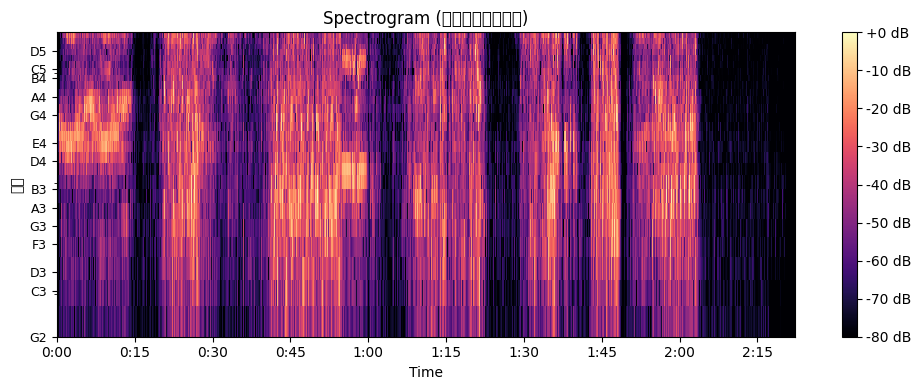

In [115]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

def hz_to_note_name(freq_hz):
    if not np.isfinite(freq_hz) or freq_hz <= 0:
        return ""
    midi = int(round(69 + 12 * np.log2(freq_hz / 440.0)))
    note_names = ["C", "C#", "D", "D#", "E", "F", "F#", "G", "G#", "A", "A#", "B"]
    note = note_names[midi % 12]
    octave = midi // 12 - 1
    return f"{note}{octave}"


y, sr = librosa.load(r"content\separated\htdemucs\my_audio\vocals.wav", sr=44100)
D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)

fig, ax = plt.subplots(figsize=(10, 4))
img = librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log', ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')

# y軸を人の歌声域に絞る（男女問わず一般的な歌唱範囲）
# 例: G2 〜 E5 くらい、約 98 Hz 〜 659 Hz
min_freq = 98.0
max_freq = 659.0
ax.set_ylim(min_freq, max_freq)
freq_ticks = np.array([98.00, 130.81, 146.83, 174.61, 196.00, 220.00, 246.94, 293.66, 329.63, 392.00, 440.00, 493.88, 523.25, 587.33, 659.25])
visible = freq_ticks[(freq_ticks >= min_freq) & (freq_ticks <= max_freq)]
if len(visible) > 0:
    ax.set_yticks(visible)
    ax.set_yticklabels([hz_to_note_name(f) for f in visible], fontsize=9)

ax.set_title('Spectrogram (音名付き・歌声域)')
ax.set_ylabel('音名')
ax.set_xlabel('Time')
plt.tight_layout()

plt.show()


In [ ]:
import numpy as np
import librosa

def estimate_time_signature(y, sr, tempo_bpm):
    hop_length = 512
    onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=hop_length)
    _, beat_frames = librosa.beat.beat_track(
        onset_envelope=onset_env,
        sr=sr,
        hop_length=hop_length,
        start_bpm=float(tempo_bpm),
    )
    beat_strengths = np.asarray([
        np.max(onset_env[max(0, frame - 2):min(len(onset_env), frame + 3)])
        for frame in beat_frames
    ])
    if len(beat_strengths) < 24 or np.std(beat_strengths) == 0:
        return "Unknown"

    centered = np.log1p(beat_strengths) - np.mean(np.log1p(beat_strengths))

    def periodicity(beats_per_bar):
        correlations = []
        for lag in range(beats_per_bar, min(3 * beats_per_bar, len(centered) // 2) + 1, beats_per_bar):
            left, right = centered[:-lag], centered[lag:]
            if np.std(left) > 0 and np.std(right) > 0:
                correlations.append(np.corrcoef(left, right)[0, 1])
        return float(np.mean(correlations)) if correlations else float("nan")

    scores = {meter: periodicity(meter) for meter in (3, 4)}
    if not all(np.isfinite(score) for score in scores.values()) or abs(scores[3] - scores[4]) < 0.05:
        return "Unknown"
    return f"{max(scores, key=scores.get)}/4"


x_sr = 200
bpm_min, bpm_max = 60, 300

# 楽曲の信号を読み込む
filepath = r"content\separated\htdemucs\my_audio\drums.wav"
y, sr = librosa.load(filepath, offset=30, duration=duration, mono=True)

# ビート検出用信号の生成
# リサンプリング & パワー信号の抽出
x = np.abs(librosa.resample(y, orig_sr=sr, target_sr=x_sr)) ** 2
x_len = len(x)

# 各BPMに対応する複素正弦波行列を生成
M = np.zeros((bpm_max, x_len), dtype=complex)
for bpm in range(bpm_min, bpm_max):
    theta = 2 * np.pi * (bpm / 60) * (np.arange(0, x_len) / x_sr)
    M[bpm] = np.exp(-1j * theta)

# 各BPMとのマッチング度合い計算
#（複素正弦波行列とビート検出用信号との内積）
x_bpm = np.abs(np.dot(M, x))

# BPMを算出
bpm = bpm_min + np.argmax(x_bpm[bpm_min:bpm_max])
time_signature = estimate_time_signature(y, sr, bpm)
print(f"{bpm} BPM, {time_signature}")

210 BPM, 4/4


In [117]:
import librosa
import numpy as np
import soundfile as sf
from pathlib import Path

OTHER_PATH = Path(r"content\separated\htdemucs\my_audio\other.wav")
BASS_PATH = Path(r"content\separated\htdemucs\my_audio\bass.wav")
VOCALS_PATH = Path(r"content\separated\htdemucs\my_audio\vocals.wav")
COMBINED_PATH = Path(r"content\separated\htdemucs\my_audio\other_bass_combined.wav")
KEY_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F',
             'F#', 'G', 'G#', 'A', 'A#', 'B']

# other.wav と bass.wav を合成して新しい解析用音声を作成
other, sr = librosa.load(OTHER_PATH, sr=None, mono=False)
bass, _ = librosa.load(BASS_PATH, sr=sr, mono=False)
vocals, _ = librosa.load(VOCALS_PATH, sr=sr, mono=False)

if other.ndim == 1:
    other = other[np.newaxis, :]
if bass.ndim == 1:
    bass = bass[np.newaxis, :]
if vocals.ndim == 1:
    vocals = vocals[np.newaxis, :]


n_frames = min(other.shape[1], bass.shape[1], vocals.shape[1])
combined = other[:, :n_frames] + bass[:, :n_frames] + vocals[:, :n_frames]

if combined.shape[0] == 1:
    combined_out = combined[0]
else:
    combined_out = combined.T

COMBINED_PATH.parent.mkdir(parents=True, exist_ok=True)
sf.write(str(COMBINED_PATH), combined_out, sr)
print(f"Combined audio saved to: {COMBINED_PATH}")

AUDIO_PATH = str(COMBINED_PATH)

MAJOR_PROFILE = np.array([6.35, 2.23, 3.48, 2.33, 4.38, 4.09,
                          2.52, 5.19, 2.39, 3.66, 2.29, 2.88])
MINOR_PROFILE = np.array([6.33, 2.68, 3.52, 5.38, 2.60, 3.53,
                          2.54, 4.75, 3.98, 2.69, 3.34, 3.17])

MAJOR_TEMPLATE = np.array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0])
MINOR_TEMPLATE = np.array([1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0])
MAJOR7_TEMPLATE = np.array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1])
DOM7_TEMPLATE = np.array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0])
MIN7_TEMPLATE = np.array([1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0])
DIM7_TEMPLATE = np.array([1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0])
HALF_DIM7_TEMPLATE = np.array([1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0])
AUGUMENTED_TEMPLATE = np.array([1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0])

def estimate_key(chroma_mean):
    major_corr = [np.corrcoef(np.roll(MAJOR_PROFILE, i), chroma_mean)[0, 1]
                  for i in range(12)]
    minor_corr = [np.corrcoef(np.roll(MINOR_PROFILE, i), chroma_mean)[0, 1]
                  for i in range(12)]

    if max(major_corr) >= max(minor_corr):
        return KEY_NAMES[np.argmax(major_corr)], 'major', major_corr
    return KEY_NAMES[np.argmax(minor_corr)], 'minor', minor_corr


def build_chord_templates():
    templates = []
    names = []
    chord_types = []
    chord_defs = [
        (MAJOR_TEMPLATE, 'maj', 'triad'),
        (MINOR_TEMPLATE, 'min', 'triad'),
        (MAJOR7_TEMPLATE, 'maj7', 'seventh'),
        (DOM7_TEMPLATE, '7', 'seventh'),
        (MIN7_TEMPLATE, 'm7', 'seventh'),
        (DIM7_TEMPLATE, 'dim7', 'seventh'),
        (HALF_DIM7_TEMPLATE, 'm7b5', 'seventh'),
        (AUGUMENTED_TEMPLATE, 'aug', 'triad'),
    ]

    for i, root in enumerate(KEY_NAMES):
        for template, suffix, kind in chord_defs:
            rolled = np.roll(template, i).astype(float)
            norm = np.linalg.norm(rolled)
            if norm > 0:
                rolled /= norm
            templates.append(rolled)
            names.append(f"{root}:{suffix}")
            chord_types.append(kind)

    return np.array(templates, dtype=float), names, np.array(chord_types)


def detect_chords(y, chroma, hop_length, sr, tempo_bpm):
    templates, chord_names, chord_types = build_chord_templates()
    triad_mask = chord_types == 'triad'
    seventh_mask = chord_types == 'seventh'

    if not np.isfinite(tempo_bpm) or tempo_bpm <= 0:
        raise ValueError("tempo_bpm must be a positive finite value")

    frames_per_beat = sr * 60 / (tempo_bpm * hop_length)
    beat_frames = np.unique(np.append(
        np.rint(np.arange(0, chroma.shape[1], frames_per_beat)).astype(int),
        chroma.shape[1],
    ))

    progression = []
    for i in range(len(beat_frames) - 1):
        start = int(beat_frames[i])
        end = int(beat_frames[i + 1])
        if end <= start:
            continue

        segment = chroma[:, start:end]
        avg = np.mean(segment, axis=1)
        if np.linalg.norm(avg) < 1e-6:
            continue
        avg /= np.linalg.norm(avg)

        corr = templates.dot(avg)
        triad_corrs = np.full_like(corr, -np.inf)
        seventh_corrs = np.full_like(corr, -np.inf)
        triad_corrs[triad_mask] = corr[triad_mask]
        seventh_corrs[seventh_mask] = corr[seventh_mask]

        best_triad_idx = int(np.argmax(triad_corrs))
        best_seventh_idx = int(np.argmax(seventh_corrs))
        best_triad_corr = triad_corrs[best_triad_idx]
        best_seventh_corr = seventh_corrs[best_seventh_idx]

        if best_triad_corr >= best_seventh_corr * 0.98:
            chord = chord_names[best_triad_idx]
        else:
            chord = chord_names[best_seventh_idx]

        time = librosa.frames_to_time((start + end) // 2, sr=sr, hop_length=hop_length)
        progression.append((time, chord))

    compressed = []
    for time, chord in progression:
        if compressed and compressed[-1][1] == chord:
            continue
        compressed.append((time, chord))
    return compressed


def seconds_to_minsec(seconds):
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes}:{secs:02d}"


def format_progression(progress):
    lines = []
    for time, chord in progress:
        lines.append(f"{seconds_to_minsec(time)}: {chord}")
    return '\n'.join(lines)

key="" 


y, sr = librosa.load(AUDIO_PATH, sr=None)
hop_length = 4096

chroma = librosa.feature.chroma_cqt(y=y, sr=sr, hop_length=hop_length)
chroma_mean = np.mean(chroma, axis=1)

key, mode, _ = estimate_key(chroma_mean)
print(f"推定キー: {key} {mode}")

progression = detect_chords(y, chroma, hop_length, sr, tempo_bpm=bpm)
if progression:
        print("\n推定コード進行（時間と共に）:")
        print(format_progression(progression))
else:
        print("コード進行の検出に失敗しました。音声が短いか、解析が難しい可能性があります。")



Combined audio saved to: content\separated\htdemucs\my_audio\other_bass_combined.wav
推定キー: A# major

推定コード進行（時間と共に）:
0:00: A#:m7
0:00: A#:maj
0:00: A#:min
0:00: A#:m7
0:02: A#:min
0:02: A#:7
0:02: A#:m7
0:03: A#:maj7
0:03: A#:min
0:04: A#:m7
0:05: A#:min
0:05: A#:7
0:06: A#:maj7
0:06: A#:m7
0:07: A#:min
0:07: A#:m7
0:08: A#:min
0:09: A#:m7b5
0:09: A#:m7
0:10: A#:maj7
0:10: A#:maj
0:10: A#:min
0:11: A#:7
0:11: A#:m7
0:12: A#:7
0:13: A#:maj7
0:14: A#:7
0:14: F:m7
0:14: A#:7
0:15: F:m7
0:15: A#:7
0:16: F:m7
0:16: A#:7
0:16: F:maj7
0:16: G#:maj7
0:17: A#:7
0:17: F:m7
0:18: A#:7
0:18: F:m7
0:18: A#:maj7
0:19: A#:7
0:19: F:m7
0:19: A#:7
0:20: F:maj7
0:20: D#:m7
0:20: A#:m7
0:20: A#:7
0:21: F:m7
0:21: A#:7
0:22: F:m7
0:22: A#:maj7
0:22: A#:7
0:22: F:m7
0:23: A#:7
0:23: F:maj7
0:23: D#:m7
0:24: A#:m7
0:24: A#:7
0:24: F:m7
0:24: A#:7
0:25: F:m7
0:25: A#:maj7
0:26: A#:7
0:26: F:maj7
0:27: D#:m7
0:27: A#:m7
0:27: A#:7
0:28: A#:maj7
0:28: A#:7
0:29: A#:maj7
0:29: A#:7
0:29: F:maj7
0:30: A#:7
0:30:

In [118]:
import sqlite3
import re
from datetime import datetime
from pathlib import Path

artist_value = track_info.get("artist") or track_info.get("uploader") or "unknown"
if isinstance(artist_value, str):
    ARTISTS = [name.strip() for name in artist_value.split(",") if name.strip()]
elif isinstance(artist_value, (list, tuple)):
    ARTISTS = [str(name).strip() for name in artist_value if str(name).strip()]
else:
    ARTISTS = [str(artist_value).strip()]
ARTISTS = list(dict.fromkeys(ARTISTS)) or ["unknown"]

def make_table_name(artist_name):
    safe_name = re.sub(r"\W+", "_", artist_name.lower(), flags=re.UNICODE).strip("_")
    return f"{safe_name or 'unknown'}"

DB_PATH = Path("song_analysis.db")
TABLE_NAMES = list(dict.fromkeys(make_table_name(name) for name in ARTISTS))
print(f"SQLite DB: {DB_PATH}")
print("アーティスト別テーブル:")
for table_name in TABLE_NAMES:
    print(f"  {table_name}")

def normalize_url_to_id(url):
    patterns = [
        r"(?:v=|vi=)([A-Za-z0-9_-]{11})",
        r"(?:youtu\.be/|/embed/)([A-Za-z0-9_-]{11})",
    ]
    for pattern in patterns:
        match = re.search(pattern, url)
        if match:
            return match.group(1)
    return "unknown"

def save_song_record(
    track_info=None,
    title=None,
    artist=None,
    album=None,
    release_date=None,
    duration=None,
    tempo_bpm=None,
    time_signature=None,
    estimated_key=None,
    estimated_mode=None,
    chord_progression=None,
):

    record = {
        'id': track_info.get('id') if track_info else 'unknown',
        'url': track_info.get('webpage_url') if track_info else 'N/A',
        'title': title or (track_info or {}).get('title') or 'N/A',
        'artist': artist or (track_info or {}).get('artist') or (track_info or {}).get('uploader') or 'N/A',
        'album': album or (track_info or {}).get('album') or 'N/A',
        'release_date': release_date or (track_info or {}).get('release_date') or 'N/A',
        'duration': duration,
        'tempo_bpm': float(tempo_bpm) if tempo_bpm is not None else None,
        'time_signature': time_signature,
        'estimated_key': estimated_key,
        'estimated_mode': estimated_mode,
        'chord_progression': chord_progression or '',
        'saved_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    conn = sqlite3.connect(DB_PATH)
    conn.execute(f'''
        CREATE TABLE IF NOT EXISTS {TABLE_NAME} (
            id TEXT PRIMARY KEY,
            url TEXT,
            title TEXT,
            artist TEXT,
            album TEXT,
            release_date TEXT,
            duration REAL,
            tempo_bpm REAL,
            time_signature TEXT,
            estimated_key TEXT,
            estimated_mode TEXT,
            chord_progression TEXT,
            saved_at TEXT
        )
    ''')

    columns = {row[1] for row in conn.execute(f"PRAGMA table_info({TABLE_NAME})")}
    if "time_signature" not in columns:
        conn.execute(f"ALTER TABLE {TABLE_NAME} ADD COLUMN time_signature TEXT")

    conn.execute(f'''
        INSERT OR REPLACE INTO {TABLE_NAME} (
            id, url, title, artist, album, release_date,
            duration, tempo_bpm, time_signature, estimated_key,
            estimated_mode, chord_progression, saved_at
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    ''', (
        record['id'],
        record['url'],
        record['title'],
        record['artist'],
        record['album'],
        record['release_date'],
        record['duration'],
        record['tempo_bpm'],
        record['time_signature'],
        record['estimated_key'],
        record['estimated_mode'],
        record['chord_progression'],
        record['saved_at'],
    ))

    conn.commit()
    conn.close()

    print(f"✅ DB保存完了: {DB_PATH}")
    print(f"  ID: {record['id']}")
    print(f"  曲名: {record['title']}")
    print(f"  アーティスト: {record['artist']}")
    print(f"  長さ: {record['duration']} 秒")
    print(f"  テンポ: {record['tempo_bpm']} BPM")
    print(f"  拍子: {record['time_signature']}")
    print(f"  推定キー: {record['estimated_key']} {record['estimated_mode']}")

for TABLE_NAME in TABLE_NAMES:
    save_song_record(
        track_info=track_info,
        duration=duration,
        tempo_bpm=bpm,
        time_signature=time_signature,
        estimated_key=key,
        estimated_mode=mode,
    )

print("\n=== SQLiteの中身を確認 ===")
for TABLE_NAME in TABLE_NAMES:
    conn = sqlite3.connect(DB_PATH)
    rows = conn.execute(f"SELECT id, title, artist, duration, tempo_bpm, time_signature, estimated_key, estimated_mode FROM {TABLE_NAME}").fetchall()
    conn.close()
    print(f"--- {DB_PATH} ---")
    for row in rows:
        print(row)


SQLite DB: song_analysis.db
アーティスト別テーブル:
  toby_fox
✅ DB保存完了: song_analysis.db
  ID: uivFFnCI8tM
  曲名: BIG SHOT
  アーティスト: Toby Fox
  長さ: 142 秒
  テンポ: 210.0 BPM
  拍子: 4/4
  推定キー: A# major

=== SQLiteの中身を確認 ===
--- song_analysis.db ---
('1TtdC745UDg', 'Flower Man', 'Toby Fox, Camellia', 192.0, 160.0, '3/4', 'E', 'major')
('uivFFnCI8tM', 'BIG SHOT', 'Toby Fox', 142.0, 210.0, '4/4', 'A#', 'major')
